In [ ]:
# Multiple Linear Regression Analysis
import pandas as pd

data = {
    "Experience": [2,5,1,8,4,10,3,6,7,2],
    "Training_Hours": [40,60,20,80,50,90,30,70,75,25],
    "Working_Hours": [38,42,35,45,40,48,37,44,46,36],
    "Projects": [3,6,2,8,5,9,4,7,7,3],
    "Productivity_Score": [62,78,55,88,72,92,65,82,85,60]
}

df = pd.DataFrame(data)
df

,Experience,Training_Hours,Working_Hours,Projects,Productivity_Score
0,2,40,38,3,62
1,5,60,42,6,78
2,1,20,35,2,55
3,8,80,45,8,88
4,4,50,40,5,72
5,10,90,48,9,92
6,3,30,37,4,65
7,6,70,44,7,82
8,7,75,46,7,85
9,2,25,36,3,60


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Experience          10 non-null     int64
 1   Training_Hours      10 non-null     int64
 2   Working_Hours       10 non-null     int64
 3   Projects            10 non-null     int64
 4   Productivity_Score  10 non-null     int64
dtypes: int64(5)
memory usage: 532.0 bytes


In [ ]:
df.isnull().sum()

,0
Experience,0
Training_Hours,0
Working_Hours,0
Projects,0
Productivity_Score,0


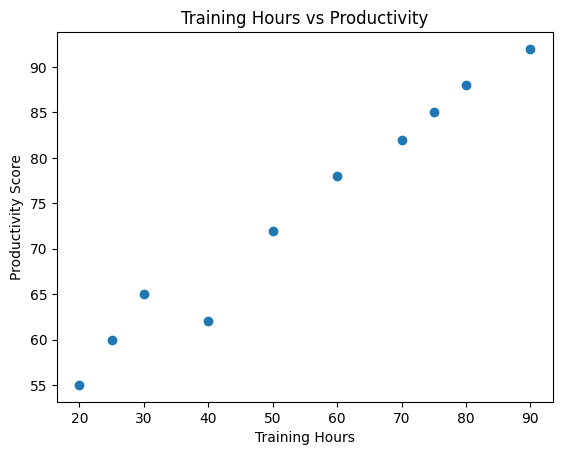

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df["Training_Hours"], df["Productivity_Score"])
plt.xlabel("Training Hours")
plt.ylabel("Productivity Score")
plt.title("Training Hours vs Productivity")
plt.show()

In [ ]:
X = df[["Experience","Training_Hours","Working_Hours","Projects"]]
y = df["Productivity_Score"]

In [ ]:
X

,Experience,Training_Hours,Working_Hours,Projects
0,2,40,38,3
1,5,60,42,6
2,1,20,35,2
3,8,80,45,8
4,4,50,40,5
5,10,90,48,9
6,3,30,37,4
7,6,70,44,7
8,7,75,46,7
9,2,25,36,3


In [ ]:
y

,Productivity_Score
0,62
1,78
2,55
3,88
4,72
5,92
6,65
7,82
8,85
9,60


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_scaled

array([[-1.00514142, -0.59750544, -0.71706255, -1.06904497],
       [ 0.07179582,  0.25607376,  0.20817945,  0.26726124],
       [-1.3641205 , -1.45108464, -1.41099406, -1.51448037],
       [ 1.14873305,  1.10965296,  0.90211095,  1.15813205],
       [-0.28718326, -0.17071584, -0.25444155, -0.17817416],
       [ 1.86669121,  1.53644256,  1.59604246,  1.60356745],
       [-0.64616234, -1.02429504, -0.94837305, -0.62360956],
       [ 0.4307749 ,  0.68286336,  0.67080045,  0.71269665],
       [ 0.78975397,  0.89625816,  1.13342146,  0.71269665],
       [-1.00514142, -1.23768984, -1.17968356, -1.06904497]])

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
X_train

array([[ 1.86669121,  1.53644256,  1.59604246,  1.60356745],
       [-1.00514142, -0.59750544, -0.71706255, -1.06904497],
       [ 0.4307749 ,  0.68286336,  0.67080045,  0.71269665],
       [-1.3641205 , -1.45108464, -1.41099406, -1.51448037],
       [-1.00514142, -1.23768984, -1.17968356, -1.06904497],
       [-0.28718326, -0.17071584, -0.25444155, -0.17817416],
       [ 1.14873305,  1.10965296,  0.90211095,  1.15813205],
       [-0.64616234, -1.02429504, -0.94837305, -0.62360956]])

In [ ]:
X_test

array([[0.78975397, 0.89625816, 1.13342146, 0.71269665],
       [0.07179582, 0.25607376, 0.20817945, 0.26726124]])

In [ ]:
y_train

,Productivity_Score
5,92
0,62
7,82
2,55
9,60
4,72
3,88
6,65


In [ ]:
y_test

,Productivity_Score
8,85
1,78


In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("R2 Score :", r2_score(y_test, y_pred))

MAE : 2.5106888361045065
MSE : 8.396082170603846
R2 Score : 0.31460553709356365


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

params = {"alpha":[0.1,1,10,100]}

grid = GridSearchCV(Ridge(), params, cv=3)

grid.fit(X_train, y_train)

print("Best Alpha :", grid.best_params_)

Best Alpha : {'alpha': 0.1}


In [ ]:
import joblib

joblib.dump(model, "productivity_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
#Testing code
model = joblib.load("productivity_model.pkl")
scaler = joblib.load("scaler.pkl")

# Experience, Training Hours, Working Hours, Projects
new_employee = [[5, 65, 42, 6]]

new_employee_scaled = scaler.transform(new_employee)

predicted_productivity = model.predict(new_employee_scaled)

print("Predicted Productivity Score :", predicted_productivity[0])

Predicted Productivity Score : 78.29928741092637


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
